# Sensitivity Analysis v3 — Corner-Solution Diagnostics & Manual Lab

**Built for the 3-struct solver API** (`CommonParams`, `UnskilledParams`,
`SkilledParams`) and the `_equalW` SMM bundles.

**Two parts.**

**Part A — hands-off assessment.** Loads the 4 saved fits, re-solves each at its
θ\*, verifies Q reproduces the saved loss, then reports: (i) the per-moment
decomposition of Q (which moments *own* the misfit), (ii) which parameters sit
on a bound, (iii) a cross-window corner map, and (iv) an automated genuine-corner
detector with a recommended set of window-independent bounds. Run top-to-bottom
and read off.

**Part B — manual lab.** Open one fit, see the local moment↔parameter
elasticities, hand-edit parameters and watch Q and every moment move, and — the
core tool — **sweep each cornered parameter across and past its bound** to
decide, per parameter, whether the corner is:

1. the **optimiser** leaving Q on the table (a better *interior* point exists),
2. a **bound in the wrong region** (Q keeps improving *past* it → widen it), or
3. a **genuine corner / moment tension** (Q is truly minimised at the limit).

> Assumes this notebook lives in `<project>/code/notebooks/`. If not, edit
> `NB_DIR` in Section 2.

## 1 · Packages

In [1]:
using LinearAlgebra, Statistics, Random, Printf
using Distributions, FastGaussQuadrature, Interpolations, Parameters
using Serialization
using DataFrames
using Plots, LaTeXStrings
using Base.Threads
gr()
Random.seed!(1234)
println("packages loaded — threads = ", Threads.nthreads())

packages loaded — threads = 10


## 2 · Paths & module includes

Includes the solver and SMM source in the same order as `smm_main.jl` /
`model_main.jl`. `candidates.jl` is intentionally **not** included (it pulls in
`QuasiMonteCarlo`/`Clustering`, which the diagnostics here never call).

In [2]:
# Edit NB_DIR if this notebook is not in <project>/code/notebooks/.
const NB_DIR       = @__DIR__
const SOLVER_DIR   = abspath(joinpath(NB_DIR, "..", "solver"))
const SMM_DIR      = abspath(joinpath(NB_DIR, "..", "smm"))
const PROJECT_ROOT = abspath(joinpath(NB_DIR, "..", ".."))
const OUTPUT_DIR   = joinpath(PROJECT_ROOT, "output")
const SMM_OUT_DIR  = joinpath(OUTPUT_DIR, "smm")
const DERIVED_DIR  = joinpath(PROJECT_ROOT, "data", "derived")

for d in (SOLVER_DIR, SMM_DIR)
    isdir(d) || error("Directory not found: $d\nEdit NB_DIR in this cell to point at your project's code/ folder.")
end

include(joinpath(SOLVER_DIR, "grids.jl"))
include(joinpath(SOLVER_DIR, "params.jl"))
include(joinpath(SOLVER_DIR, "unskilled.jl"))
include(joinpath(SOLVER_DIR, "skilled.jl"))
include(joinpath(SOLVER_DIR, "solver.jl"))
include(joinpath(SOLVER_DIR, "equilibrium.jl"))
include(joinpath(SMM_DIR, "moments.jl"))
include(joinpath(SMM_DIR, "smm_params.jl"))
include(joinpath(SMM_DIR, "smm.jl"))

println("solver + SMM modules loaded.")
println("Looking for SMM bundles in: ", SMM_OUT_DIR)

solver + SMM modules loaded.
Looking for SMM bundles in: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/output/smm


## 3 · Config

`W_SUFFIX` must match how the bundles were saved (`_equalW` for
`W_COND_TARGET = 2.0`). `CORNER_TOL` is the fraction-of-width within which a
parameter counts as "on a bound". Part B settings are at the bottom.

In [3]:
# Which fits to assess and the weight-matrix suffix used when they were saved.
const WINDOWS    = [:base_fc, :crisis_fc, :base_covid, :crisis_covid]
const W_SUFFIX   = "_equalW"     # matches W_COND_TARGET = 2.0 in smm_main.jl
const CORNER_TOL = 0.02          # |value - bound| < TOL*(ub-lb) ⇒ flagged as a corner

# ── Manual-lab settings (Part B) ─────────────────────────────────────────────
const LAB_WINDOW = :base_fc   # which fit to open in the lab
const LAB_NX     = 96            # grid for lab re-solves/sweeps (lower=faster; 120=estimation grid)
const SWEEP_PTS  = 13            # points per corner sweep

# Generous *hard* admissibility ranges for sweeps — wider than the estimation
# box but still valid. Keyed by the bare field name (μ/η/… shared across blocks).
const HARD = Dict{Symbol,Tuple{Float64,Float64}}(
    :a_ℓ=>(0.05,15.0), :b_ℓ=>(0.05,15.0), :c=>(-2.0,14.0),
    :PU=>(0.05,12.0),  :gamma_PS=>(1.0,16.0), :α_U=>(0.01,30.0),
    :a_Γ=>(0.05,15.0), :b_Γ=>(0.05,16.0),
    :μ=>(0.01,2.5),    :η=>(0.02,0.98), :k=>(0.001,2.5),
    :β=>(0.02,0.98),   :λ=>(0.001,1.2), :σ=>(0.0,0.30),
    :bU=>(0.0,3.0),    :bT=>(0.0,3.0),  :bS=>(0.0,3.0),
)
hard_range(nm::Symbol) = get(HARD, nm, (-Inf, Inf))

silent(sim) = update(sim; verbose = 0)   # `update` defined in Section 4
println("config set — assessing ", WINDOWS, " ; lab window = ", LAB_WINDOW)

config set — assessing [:base_fc, :crisis_fc, :base_covid, :crisis_covid] ; lab window = base_fc


## 4 · Core helpers

`update`/`set_field` copy an immutable `@kwdef` struct with some fields changed.
`solve_report` solves at `(cp,up,sp)` and returns Q, the per-moment
decomposition, feasibility flags, and the raw equilibrium objects. The Q
decomposition is **exact** for the diagonal weight schemes (`equal`/`diagonal`/
`compressed`); for a full Σ̂⁻¹ it shows the diagonal part only.

In [4]:
# ---- struct editing -------------------------------------------------------
function update(s; kwargs...)
    T = typeof(s); over = Dict{Symbol,Any}(kwargs)
    vals = Dict{Symbol,Any}(f => get(over, f, getfield(s, f)) for f in fieldnames(T))
    return T(; vals...)
end
function set_field(s, f::Symbol, v)
    T = typeof(s)
    vals = Dict{Symbol,Any}(g => (g === f ? v : getfield(s, g)) for g in fieldnames(T))
    return T(; vals...)
end

# ---- block-aware read/write on (cp,up,sp) ---------------------------------
get_par(cp,up,sp, blk::Symbol, nm::Symbol) =
    blk === :common ? getfield(cp,nm) : blk === :unsk ? getfield(up,nm) : getfield(sp,nm)
function put_par(cp,up,sp, blk::Symbol, nm::Symbol, v)
    blk === :common && return (set_field(cp,nm,v), up, sp)
    blk === :unsk   && return (cp, set_field(up,nm,v), sp)
    return (cp, up, set_field(sp,nm,v))
end

finite_only(v) = (x = filter(isfinite, v); isempty(x) ? Float64[0.0] : x)

# ---- feasibility (mirrors the filters inside smm_objective) ---------------
function feasibility(obj, sres)
    notes = String[]
    sres.ok || push!(notes, "solver not fully converged")
    obj.agg_eU < 1e-12 && push!(notes, "unskilled segment empty")
    obj.agg_eS < 1e-12 && push!(notes, "skilled segment empty")
    τ = collect(obj.tauT)
    if all(==(0.0), τ);      push!(notes, "τ≡0 (nobody trains)")
    elseif all(==(1.0), τ);  push!(notes, "τ≡1 (everybody trains)")
    end
    all(t -> t == 0.0 || t == 1.0, τ) || push!(notes, "τ non-binary")
    dτ = diff(τ)
    (any(<(0.0), dτ) || count(!=(0.0), dτ) > 1) && push!(notes, "τ non-monotone/≥2 jumps")
    return isempty(notes), notes
end

# ---- per-moment Q decomposition (exact for diagonal W) --------------------
function decompose_Q(mm, spec)
    ks = Symbol[]; tgt = Float64[]; mod = Float64[]
    for k in keys(spec.moments)
        spec.moments[k].weight > 0 || continue
        hasproperty(mm, k) || continue
        push!(ks, k); push!(tgt, spec.moments[k].value); push!(mod, getproperty(mm, k))
    end
    dev = mod .- tgt
    Wd  = Float64[spec.W[i,i] for i in eachindex(ks)]
    contrib = Wd .* dev.^2 ./ spec.q_scale
    Qtot = sum(contrib)
    reldev = Float64[tgt[i] != 0 ? dev[i]/tgt[i] : NaN for i in eachindex(ks)]
    df = DataFrame(moment = ks, target = tgt, model = mod, abs_dev = dev,
                   rel_dev_pct = 100 .* reldev, contribution = contrib,
                   pct_of_Q = 100 .* contrib ./ max(Qtot, eps()))
    sort!(df, :contribution, rev = true)
    return df, Qtot
end

# ---- corner table ---------------------------------------------------------
function corner_table(theta, spec; tol = CORNER_TOL)
    rows = NamedTuple[]
    for (i, ps) in enumerate(spec.free)
        x = _to_constrained(theta[i], ps.lb, ps.ub)
        w = ps.ub - ps.lb
        dlo = w > 0 ? (x - ps.lb)/w : 0.0
        dhi = w > 0 ? (ps.ub - x)/w : 0.0
        frac = min(dlo, dhi)
        push!(rows, (param = string(ps.block)*"_"*string(ps.name),
                     block = ps.block, name = ps.name, value = x, lb = ps.lb, ub = ps.ub,
                     frac_to_bound = frac, nearest = (dlo <= dhi ? :lb : :ub),
                     cornered = frac < tol))
    end
    df = DataFrame(rows); sort!(df, :frac_to_bound); return df
end

# ---- solve at (cp,up,sp) and assemble a report ----------------------------
function solve_report(cp, up, sp; spec, sim, Nx, Np_U = Nx, Np_S = Nx, label = :fit)
    try
        model, sres = solve_model(cp, up, sp, sim; Nx = Nx, Np_U = Np_U, Np_S = Np_S)
        obj = compute_equilibrium_objects(model)
        mm  = model_moments(obj)
        Q   = compute_loss_matrix(mm, spec, spec.W)
        feas, notes = feasibility(obj, sres)
        decomp, _   = decompose_Q(mm, spec)
        return (label=label, ok=true, cp=cp, up=up, sp=sp, model=model, result=sres,
                obj=obj, mm=mm, Q=Q, feasible=feas, notes=notes, decomp=decomp)
    catch err
        return (label=label, ok=false, cp=cp, up=up, sp=sp, Q=Inf, feasible=false,
                notes=["solve/eval threw: $(err)"])
    end
end
println("helpers defined.")

helpers defined.


# Part A — Hands-off assessment of the 4 fits

Loads every available `smm_result_<window>_equalW.jls`, re-solves at θ\* on the
estimation grid, and checks that the recomputed Q matches the saved loss.

In [5]:
# Load every available SMM bundle: (result, spec, sim).
bundles = Dict{Symbol,Any}()
status  = DataFrame(window=Symbol[], file=String[], state=String[])
for w in WINDOWS
    path = joinpath(SMM_OUT_DIR, "smm_result_$(w)$(W_SUFFIX).jls")
    if !isfile(path)
        push!(status, (w, basename(path), "MISSING")); continue
    end
    b = _load_smm_bundle(path; delete_on_fail=false, label="bundle($w)")
    if b === nothing
        push!(status, (w, basename(path), "UNREADABLE")); continue
    end
    blocks_ok = all(ps -> ps.block in (:common,:unsk,:skl), b.spec.free)
    bundles[w] = b
    push!(status, (w, basename(path), blocks_ok ? "OK" : "STALE (old block names)"))
end
status

┌ Warning: Failed to deserialize bundle(crisis_fc) (stale format — will overwrite): EOFError()
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/smm/smm.jl:43


Row,window,file,state
,Symbol,String,String
1,base_fc,smm_result_base_fc_equalW.jls,OK
2,crisis_fc,smm_result_crisis_fc_equalW.jls,UNREADABLE
3,base_covid,smm_result_base_covid_equalW.jls,OK
4,crisis_covid,smm_result_crisis_covid_equalW.jls,OK


In [6]:
# Re-solve each fit at θ* (estimation grid) and verify Q. Stale bundles (old
# block names, or a moment set that no longer matches the model) get corner-only
# treatment; failed re-solves are flagged.
reports = Dict{Symbol,Any}()
verify  = DataFrame(window=Symbol[], Q_saved=Float64[], Q_resolved=Float64[],
                    absΔ=Float64[], converged=Bool[], feasible=Bool[], n_corners=Int[])
for w in WINDOWS
    haskey(bundles, w) || continue
    b = bundles[w]; res = b.result; spec = b.spec
    ct = corner_table(res.theta_opt, spec); ncorner = count(ct.cornered)
    blocks_ok  = all(ps -> ps.block in (:common,:unsk,:skl), spec.free)
    active_ms  = Symbol[k for k in keys(spec.moments) if spec.moments[k].weight > 0]
    moments_ok = all(in(Set(MOMENT_NAMES)), active_ms)
    if !blocks_ok || !moments_ok
        why = !blocks_ok ? "old block names" :
              "moment set changed — re-run the SMM to regenerate bundles"
        @printf("[%-13s] STALE bundle (%s) — corner check only (saved Q=%.4f, converged=%s)\n",
                w, why, res.loss_opt, res.converged)
        reports[w] = (stale=true, corners=ct, Q_saved=res.loss_opt, spec=spec, res=res)
        push!(verify, (w, res.loss_opt, NaN, NaN, res.converged, false, ncorner)); continue
    end
    cp,up,sp = unpack_θ(res.theta_opt, spec)
    rep = solve_report(cp,up,sp; spec=spec, sim=silent(spec.sim),
                       Nx=spec.run.Nx, Np_U=spec.run.Np_U, Np_S=spec.run.Np_S, label=w)
    if !rep.ok
        @printf("[%-13s] RE-SOLVE FAILED: %s\n", w, join(rep.notes, "; "))
        reports[w] = (stale=false, corners=ct, Q_saved=res.loss_opt, spec=spec, res=res)
        push!(verify, (w, res.loss_opt, Inf, Inf, res.converged, false, ncorner)); continue
    end
    reports[w] = (stale=false, rep=rep, corners=ct, decomp=rep.decomp,
                  Q_saved=res.loss_opt, spec=spec, res=res, cp=cp, up=up, sp=sp)
    push!(verify, (w, res.loss_opt, rep.Q, abs(rep.Q-res.loss_opt),
                   res.converged, rep.feasible, ncorner))
    @printf("[%-13s] Q_saved=%.4f  Q_resolved=%.4f  |Δ|=%.2e  conv=%s  feasible=%s  corners=%d\n",
            w, res.loss_opt, rep.Q, abs(rep.Q-res.loss_opt), res.converged, rep.feasible, ncorner)
    isempty(rep.notes) || println("            feasibility: ", join(rep.notes, "; "))
end
println("\n(|Δ| should be ~0; a large gap means the runtime grid/tol differs from the saved run.)")
verify

[base_fc      ] Q_saved=1.4382  Q_resolved=1.4382  |Δ|=0.00e+00  conv=true  feasible=true  corners=2
[base_covid   ] Q_saved=3.1456  Q_resolved=3.1456  |Δ|=0.00e+00  conv=true  feasible=true  corners=5
[crisis_covid ] STALE bundle (moment set changed — re-run the SMM to regenerate bundles) — corner check only (saved Q=1.6873, converged=true)

(|Δ| should be ~0; a large gap means the runtime grid/tol differs from the saved run.)


Row,window,Q_saved,Q_resolved,absΔ,converged,feasible,n_corners
,Symbol,Float64,Float64,Float64,Bool,Bool,Int64
1,base_fc,1.43824,1.43824,0.0,true,true,2
2,base_covid,3.14557,3.14557,0.0,true,true,5
3,crisis_covid,1.68726,NaN,NaN,true,false,4


### 4.A · Per-moment Q decomposition — who owns the misfit

For each fit, moments are sorted by their share of Q. `rel_dev_pct` is the
percentage miss; `pct_of_Q` is how much of the objective that single moment
explains. A handful of rows near the top (or any moment with a tiny `target`
inflating its weight) is the story — not the scalar Q.

In [7]:
for w in WINDOWS
    (haskey(reports,w) && haskey(reports[w], :decomp)) || continue
    @printf("\n========== %s   (Q = %.4f) ==========\n", w, reports[w].rep.Q)
    display(reports[w].decomp)
end

Row,moment,target,model,abs_dev,rel_dev_pct,contribution,pct_of_Q
,Symbol,Float64,Float64,Float64,Float64,Float64,Float64
1,emp_cm3_U,0.170862,0.0143965,-0.156465,-91.5742,0.838583,58.3062
2,emp_var_U,0.254256,0.10232,-0.151936,-59.7572,0.357093,24.8285
3,theta_U,0.434632,0.557429,0.122796,28.253,0.079823,5.55005
4,theta_S,1.21065,0.880314,-0.330331,-27.2856,0.0744502,5.17648
5,ur_S,0.0260133,0.029542,0.00352866,13.5648,0.0184004,1.27937
6,jfr_U,0.302524,0.268237,-0.0342868,-11.3336,0.012845,0.893106
7,ee_rate_S,0.00800116,0.00881655,0.000815398,10.191,0.0103857,0.72211
8,sep_rate_S,0.00624105,0.00564592,-0.000595135,-9.53582,0.00909318,0.632244
9,mean_wage_U,0.926507,0.840616,-0.0858908,-9.27038,0.008594,0.597537


Row,moment,target,model,abs_dev,rel_dev_pct,contribution,pct_of_Q
,Symbol,Float64,Float64,Float64,Float64,Float64,Float64
1,emp_cm3_U,0.262403,-4.21815e-5,-0.262445,-100.016,1.00032,31.801
2,emp_var_U,0.285969,0.00129576,-0.284673,-99.5469,0.990958,31.5033
3,theta_U,0.753438,0.264183,-0.489254,-64.9363,0.421672,13.4053
4,emp_cm3_S,0.351389,0.128807,-0.222582,-63.3434,0.401238,12.7557
5,jfr_U,0.296387,0.38546,0.089073,30.053,0.0903181,2.87128
6,p25_wage_U,0.548242,0.680165,0.131923,24.063,0.0579027,1.84077
7,mean_wage_U,0.916614,0.706384,-0.21023,-22.9355,0.0526036,1.67231
8,ur_S,0.0246717,0.0300802,0.00540849,21.9218,0.0480567,1.52776
9,p25_wage_S,0.841117,0.713351,-0.127765,-15.19,0.0230735,0.733524



========== base_fc   (Q = 1.4382) ==========

========== base_covid   (Q = 3.1456) ==========


### 4.B · Corner report

Parameters sorted by distance to the nearest bound (closest first). `cornered`
is true when within `CORNER_TOL` of a bound.

In [8]:
for w in WINDOWS
    haskey(reports,w) || continue
    @printf("\n========== %s — parameters by distance to nearest bound ==========\n", w)
    display(reports[w].corners)
end

Row,param,block,name,value,lb,ub,frac_to_bound,nearest,cornered
,String,Symbol,Symbol,Float64,Float64,Float64,Float64,Symbol,Bool
1,common_a_ℓ,common,a_ℓ,7.99463,0.01,8.0,0.000672694,ub,true
2,unsk_bU,unsk,bU,0.0344796,0.0,2.0,0.0172398,lb,true
3,unsk_α_U,unsk,α_U,0.614674,0.01,20.0,0.0302488,lb,false
4,common_b_ℓ,common,b_ℓ,0.236522,0.01,7.0,0.0324066,lb,false
5,skl_ξ,skl,ξ,0.00561424,0.0,0.1,0.0561424,lb,false
6,skl_bS,skl,bS,0.208929,0.0,2.0,0.104465,lb,false
7,unsk_k,unsk,k,1.33823,0.001,1.5,0.107922,ub,false
8,common_c,common,c,10.7157,0.1,12.0,0.107928,ub,false
9,skl_a_Γ,skl,a_Γ,1.33893,0.01,10.0,0.133026,lb,false


Row,param,block,name,value,lb,ub,frac_to_bound,nearest,cornered
,String,Symbol,Symbol,Float64,Float64,Float64,Float64,Symbol,Bool
1,unsk_bT,unsk,bT,0.000127401,0.0,2.0,6.37006e-5,lb,true
2,skl_k,skl,k,0.00926313,0.001,1.5,0.00551243,lb,true
3,skl_β,skl,β,0.974462,0.05,0.98,0.00595512,ub,true
4,skl_ξ,skl,ξ,0.00179675,0.0,0.1,0.0179675,lb,true
5,common_b_ℓ,common,b_ℓ,0.145741,0.01,7.0,0.0194193,lb,true
6,skl_bS,skl,bS,0.0491961,0.0,2.0,0.0245981,lb,false
7,unsk_PU,unsk,PU,0.73225,0.5,7.0,0.0357308,lb,false
8,common_a_ℓ,common,a_ℓ,7.69393,0.01,8.0,0.0383069,ub,false
9,unsk_α_U,unsk,α_U,19.1437,0.01,20.0,0.0428374,ub,false


Row,param,block,name,value,lb,ub,frac_to_bound,nearest,cornered
,String,Symbol,Symbol,Float64,Float64,Float64,Float64,Symbol,Bool
1,skl_k,skl,k,0.00735283,0.001,1.5,0.00423805,lb,true
2,skl_η,skl,η,0.891911,0.1,0.9,0.0101112,ub,true
3,skl_β,skl,β,0.938679,0.05,0.95,0.0125787,ub,true
4,unsk_α_U,unsk,α_U,0.328758,0.01,20.0,0.0159459,lb,true
5,skl_σ,skl,σ,0.00426128,0.0,0.15,0.0284085,lb,false
6,unsk_η,unsk,η,0.85513,0.1,0.9,0.0560879,ub,false
7,unsk_λ,unsk,λ,0.659942,0.001,0.7,0.0573074,ub,false
8,skl_b_Γ,skl,b_Γ,9.33937,0.01,10.0,0.066129,ub,false
9,unsk_k,unsk,k,0.142681,0.001,1.5,0.094517,lb,false



========== base_fc — parameters by distance to nearest bound ==========

========== base_covid — parameters by distance to nearest bound ==========

========== crisis_covid — parameters by distance to nearest bound ==========


### 4.C · Cross-window overview

In [9]:
top_misfit(decomp; k=3) = join([string(decomp.moment[i]) for i in 1:min(k,nrow(decomp))], ", ")
function cornered_list(ct)
    c = ct[ct.cornered, :]
    isempty(c) ? "(none)" : join([string(c.param[i])*"@"*string(c.nearest[i]) for i in 1:nrow(c)], ", ")
end

summary = DataFrame(window=Symbol[], Q=Float64[], converged=Bool[], feasible=Bool[],
                    n_corners=Int[], cornered=String[], top_misfit_moments=String[])
for w in WINDOWS
    haskey(reports,w) || continue
    r = reports[w]
    has = haskey(r, :decomp)
    Qv   = has ? r.rep.Q : r.Q_saved
    feas = has ? r.rep.feasible : false
    tm   = has ? top_misfit(r.decomp) : (get(r,:stale,false) ? "(stale)" : "(re-solve failed)")
    push!(summary, (w, Qv, r.res.converged, feas, count(r.corners.cornered), cornered_list(r.corners), tm))
end
summary

Row,window,Q,converged,feasible,n_corners,cornered,top_misfit_moments
,Symbol,Float64,Bool,Bool,Int64,String,String
1,base_fc,1.43824,true,true,2,"common_a_ℓ@ub, unsk_bU@lb","emp_cm3_U, emp_var_U, theta_U"
2,base_covid,3.14557,true,true,5,"unsk_bT@lb, skl_k@lb, skl_β@ub, skl_ξ@lb, common_b_ℓ@lb","emp_cm3_U, emp_var_U, theta_U"
3,crisis_covid,1.68726,true,false,4,"skl_k@lb, skl_η@ub, skl_β@ub, unsk_α_U@lb",(stale)


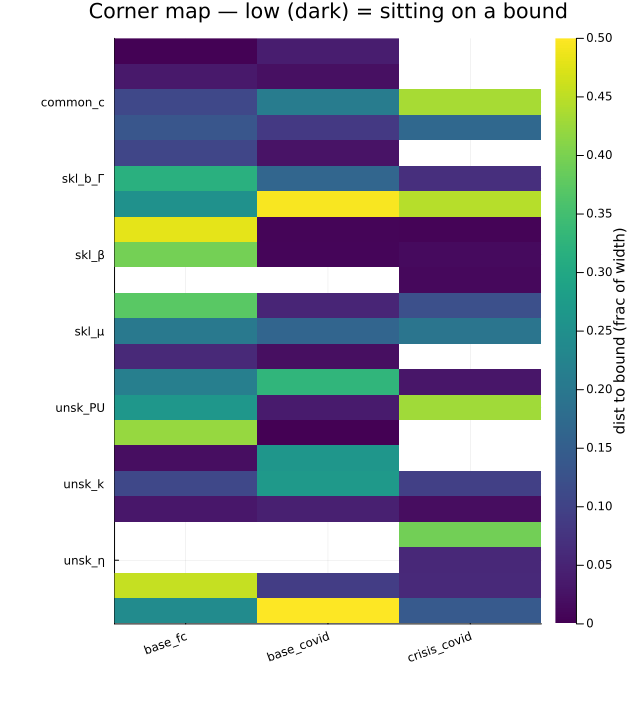

In [10]:
# Corner map: distance-to-nearest-bound for every free parameter × window.
# Dark/low = on a bound. Blank (NaN) = parameter fixed in that window.
wins = [w for w in WINDOWS if haskey(reports,w)]
allparams = sort(unique(vcat([reports[w].corners.param for w in wins]...)))
Z = fill(NaN, length(allparams), length(wins))
for (j,w) in enumerate(wins)
    ct = reports[w].corners
    for i in 1:nrow(ct)
        r = findfirst(==(ct.param[i]), allparams)
        r === nothing || (Z[r,j] = ct.frac_to_bound[i])
    end
end
heatmap(string.(wins), allparams, Z;
        c=:viridis, clims=(0,0.5), colorbar_title="dist to bound (frac of width)",
        title="Corner map — low (dark) = sitting on a bound", xrotation=20, yflip=true,
        size=(640, 24*length(allparams)+150), left_margin=10Plots.mm, bottom_margin=6Plots.mm)

## 4.D · Genuine corner detector (all windows)

Section 4.B flags a parameter as "cornered" purely by **proximity** to a bound.
That alone does not say whether the bound is *binding the economics* or just
*sitting where the optimiser stopped*. Before the manual lab, this part settles
it automatically for **all four windows at once**.

For every cornered parameter in every (re-solved) window, the other parameters
are held at the fit and the parameter is swept from inside the estimation box to
a little past its binding bound, re-solving the model at each step. The verdict
reads off two behaviours *around the bound*:

- **Q(θ)** — does the objective keep falling past the bound (the box is in the
  wrong region), dip to a strictly interior minimum (the optimiser missed it),
  bottom out *at* the bound (a genuine corner), or barely move at all (the
  parameter is weakly identified)?
- **(model − target)/target** of the moment the sweep moves most — does pushing
  past the bound drive that moment onto its target (so the bound is the only
  thing preventing a match), or does the miss persist regardless (genuine moment
  tension)?

A corner is **GENUINE** only when Q is minimised at/near the bound *and* no
feasible point past it improves the fit. `reldev_fit` / `reldev_past` report the
dominant moment's relative deviation at the fit and at the far (past-the-bound)
end of the sweep, so the moment behaviour behind each verdict is visible.


In [11]:
# Detector settings (reuse the lab grid; probe a little further past the bound
# than Section 7 so "keeps falling" is distinguishable from "bottoms out").
const DETECT_NX    = LAB_NX      # re-solve grid for the detector
const DETECT_PTS   = SWEEP_PTS   # points per sweep
const DETECT_TOL   = 0.01        # relative Q change that counts as an improvement
const DETECT_PAST  = 0.30        # how far past the bound to probe (fraction of box width)
const BOUND_MARGIN = 0.10        # widen past the best improving point (fraction of box width)

# Sweep one parameter from inside the box to past its binding bound, others held
# at the fit. Returns the grid, Q, feasibility flags and the moment matrix.
function corner_sweep(cp, up, sp, blk, nm, spec; sim, Nx, npts = DETECT_PTS)
    ps = first(p for p in spec.free if p.block === blk && p.name === nm)
    v0 = get_par(cp, up, sp, blk, nm)
    nearest = abs(v0 - ps.lb) <= abs(ps.ub - v0) ? :lb : :ub
    w = ps.ub - ps.lb; hlo, hhi = hard_range(nm)
    lo, hi = nearest === :ub ? (max(ps.ub - 0.6w, hlo), min(ps.ub + DETECT_PAST * w, hhi)) :
                               (max(ps.lb - DETECT_PAST * w, hlo), min(ps.lb + 0.6w, hhi))
    hi = max(hi, lo + 1e-6)
    grid = collect(range(lo, hi; length = npts))
    active = Symbol[k for k in keys(spec.moments) if spec.moments[k].weight > 0]
    Qs = fill(NaN, npts); feas = falses(npts); M = fill(NaN, npts, length(active))
    for (t, v) in enumerate(grid)
        try
            c, u, s = put_par(cp, up, sp, blk, nm, v)
            model, r = solve_model(c, u, s, sim; Nx = Nx, Np_U = Nx, Np_S = Nx)
            obj = compute_equilibrium_objects(model); mm = model_moments(obj)
            Qs[t]   = compute_loss_matrix(mm, spec, spec.W)
            feas[t] = feasibility(obj, r)[1]
            for (j, k) in enumerate(active); M[t, j] = getproperty(mm, k); end
        catch
        end
    end
    return (ps = ps, v0 = v0, nearest = nearest, grid = grid,
            Q = Qs, feas = feas, active = active, M = M)
end

# Classify a sweep from the behaviour of Q and the dominant moment's relative
# deviation around the bound:
#   FLAT (weak id)  — Q barely moves across the whole sweep.
#   WIDEN BOUND     — a feasible point past the bound improves Q (box too tight).
#   OPTIMISER       — a strictly interior point improves Q (global search missed).
#   GENUINE         — Q minimised at/near the bound; no feasible point past it helps.
function classify_corner(sw, Q0, spec; tol = DETECT_TOL)
    ok = isfinite.(sw.Q) .& sw.feas
    ps = sw.ps; eps_w = 1e-6 * (ps.ub - ps.lb)
    if !any(ok)
        return (verdict = "INFEASIBLE", genuine = false, x_best = NaN, q_best = NaN,
                dom_moment = :none, reldev_fit = NaN, reldev_past = NaN, widen_to = NaN)
    end
    q = copy(sw.Q); q[.!ok] .= Inf
    i = argmin(q); x_best = sw.grid[i]; q_best = q[i]
    qfin = sw.Q[ok]; qrange = maximum(qfin) - minimum(qfin)
    flat     = qrange < tol * max(Q0, eps())
    interior = (x_best > ps.lb + eps_w) && (x_best < ps.ub - eps_w)
    beyond   = sw.nearest === :ub ? (x_best > ps.ub + eps_w) : (x_best < ps.lb - eps_w)
    improved = q_best < Q0 * (1 - tol)

    # dominant moment = the active moment the sweep moves most (by range)
    rng  = [maximum(finite_only(sw.M[:, j])) - minimum(finite_only(sw.M[:, j]))
            for j in 1:length(sw.active)]
    jdom = isempty(rng) ? 1 : argmax(rng); dom = sw.active[jdom]
    tj   = spec.moments[dom].value
    rel(x) = tj != 0 ? (x - tj) / tj : (x - tj)
    ifit  = argmin(abs.(sw.grid .- sw.v0))
    ipast = sw.nearest === :ub ? length(sw.grid) : 1
    reldev_fit  = rel(sw.M[ifit,  jdom])
    reldev_past = rel(sw.M[ipast, jdom])

    verdict = flat                    ? "FLAT (weak id)" :
              (beyond   && improved)  ? "WIDEN BOUND"    :
              (interior && improved)  ? "OPTIMISER"      : "GENUINE"
    widen_to = verdict == "WIDEN BOUND" ? x_best : NaN
    return (verdict = verdict, genuine = (verdict == "GENUINE"),
            x_best = x_best, q_best = q_best, dom_moment = dom,
            reldev_fit = reldev_fit, reldev_past = reldev_past, widen_to = widen_to)
end
println("corner detector defined.")


corner detector defined.


In [12]:
# Run the detector for every cornered parameter in every re-solved window.
# Each sweep is cached in `corner_sweeps[(window, param)]` for the bounds step.
corner_sweeps = Dict{Tuple{Symbol,String},Any}()
corner_diag = DataFrame(window = Symbol[], param = String[], bound = Symbol[],
                        fit = Float64[], Q0 = Float64[], verdict = String[],
                        best_x = Float64[], best_Q = Float64[],
                        dom_moment = String[], reldev_fit_pct = Float64[],
                        reldev_past_pct = Float64[])
for w in WINDOWS
    (haskey(reports, w) && haskey(reports[w], :decomp)) || continue
    r  = reports[w]
    ct = r.corners; cornered = ct[ct.cornered, :]
    nrow(cornered) == 0 && continue
    # Reference Q on the DETECT_NX grid (compare like-with-like against the sweep).
    base = solve_report(r.cp, r.up, r.sp; spec = r.spec, sim = silent(r.spec.sim),
                        Nx = DETECT_NX, label = :detect_base)
    Q0 = base.ok ? base.Q : r.rep.Q
    for rr in eachrow(cornered)
        sw = corner_sweep(r.cp, r.up, r.sp, rr.block, rr.name, r.spec;
                          sim = silent(r.spec.sim), Nx = DETECT_NX)
        cl = classify_corner(sw, Q0, r.spec)
        corner_sweeps[(w, rr.param)] = (sw = sw, cl = cl, Q0 = Q0)
        push!(corner_diag, (w, rr.param, sw.nearest, sw.v0, Q0, cl.verdict,
                            cl.x_best, cl.q_best, string(cl.dom_moment),
                            100 * cl.reldev_fit, 100 * cl.reldev_past))
    end
end
sort!(corner_diag, [:param, :window])
if nrow(corner_diag) == 0
    println("No cornered parameters in any re-solved window (CORNER_TOL = $CORNER_TOL).")
else
    println("Per-(window, parameter) corner verdicts:")
    display(corner_diag)
    @printf("\nGENUINE %d / %d   |   WIDEN BOUND %d   |   OPTIMISER %d   |   FLAT %d   |   INFEASIBLE %d\n",
            count(==("GENUINE"), corner_diag.verdict), nrow(corner_diag),
            count(==("WIDEN BOUND"), corner_diag.verdict),
            count(==("OPTIMISER"), corner_diag.verdict),
            count(==("FLAT (weak id)"), corner_diag.verdict),
            count(==("INFEASIBLE"), corner_diag.verdict))
end


Row,window,param,bound,fit,Q0,verdict,best_x,best_Q,dom_moment,reldev_fit_pct,reldev_past_pct
,Symbol,String,Symbol,Float64,Float64,String,Float64,Float64,String,Float64,Float64
1,base_fc,common_a_ℓ,ub,7.99463,3.35584,WIDEN BOUND,8.59925,1.47716,theta_U,29.0397,30.6021
2,base_covid,common_b_ℓ,lb,0.145741,3.21665,GENUINE,0.05,3.48798,theta_U,-63.5327,-63.5327
3,base_covid,skl_k,lb,0.00926313,3.21665,FLAT (weak id),0.001,129.764,theta_S,1094.32,1094.32
4,base_covid,skl_β,ub,0.974462,3.21665,GENUINE,0.98,3.33605,theta_S,-20.699,-20.699
5,base_covid,skl_ξ,lb,0.00179675,3.21665,GENUINE,0.0075,5.14208,theta_S,6.7175,20.7452
6,base_covid,unsk_bT,lb,0.000127401,3.21665,GENUINE,0.1,3.21665,theta_U,-66.8868,-66.8868
7,base_fc,unsk_bU,lb,0.0344796,3.35584,GENUINE,0.0,3.57704,theta_S,-27.4571,-27.4571


Per-(window, parameter) corner verdicts:

GENUINE 5 / 7   |   WIDEN BOUND 1   |   OPTIMISER 0   |   FLAT 1   |   INFEASIBLE 0


### 4.E · Window-independent bounds calculator

The estimation uses one parameter box for every window, so the recommendation
must too. For each parameter the original bound is widened just far enough to
contain every improving point *any* window found past it (the `WIDEN BOUND`
verdicts above), plus a margin so the new optimum is interior rather than a fresh
corner, and is then clipped to the `HARD` admissibility range. Bounds never
shrink. Parameters that are never cornered — or whose corners are `GENUINE`,
`FLAT`, or `OPTIMISER` (no improvement *past* the bound) — keep their original
bounds. The result is a single `(lb, ub)` per parameter, identical across all
four windows.


In [13]:
# Aggregate the WIDEN-BOUND verdicts across windows into ONE box per parameter.
# Original (window-independent) bounds, read from any window where the param is free.
orig_lb = Dict{String,Float64}(); orig_ub = Dict{String,Float64}()
pblock  = Dict{String,Symbol}();  pname   = Dict{String,Symbol}()
for w in WINDOWS
    haskey(reports, w) || continue
    for ps in reports[w].spec.free
        p = string(ps.block) * "_" * string(ps.name)
        orig_lb[p] = ps.lb; orig_ub[p] = ps.ub
        pblock[p]  = ps.block; pname[p] = ps.name
    end
end

# Furthest improving point past each side, pooled over windows, with the windows
# that asked for the widening.
want_lo = Dict{String,Float64}(); want_hi = Dict{String,Float64}()
drivers = Dict{String,Vector{String}}()
for ((w, p), s) in corner_sweeps
    s.cl.verdict == "WIDEN BOUND" || continue
    if s.sw.nearest === :ub
        want_hi[p] = max(get(want_hi, p, -Inf), s.cl.widen_to)
    else
        want_lo[p] = min(get(want_lo, p,  Inf), s.cl.widen_to)
    end
    push!(get!(drivers, p, String[]), string(w))
end

new_bounds = DataFrame(param = String[], block = Symbol[], name = Symbol[],
                       orig_lb = Float64[], orig_ub = Float64[],
                       new_lb = Float64[], new_ub = Float64[],
                       changed = Bool[], driven_by = String[])
for p in sort(collect(keys(orig_lb)))
    lb0 = orig_lb[p]; ub0 = orig_ub[p]
    hlo, hhi = hard_range(pname[p]); wdt = ub0 - lb0
    nlb = lb0; nub = ub0
    haskey(want_lo, p) && (nlb = clamp(min(lb0, want_lo[p] - BOUND_MARGIN * wdt), hlo, lb0))
    haskey(want_hi, p) && (nub = clamp(max(ub0, want_hi[p] + BOUND_MARGIN * wdt), ub0, hhi))
    changed = !(nlb ≈ lb0 && nub ≈ ub0)
    push!(new_bounds, (p, pblock[p], pname[p], lb0, ub0, nlb, nub, changed,
                       join(sort(unique(get(drivers, p, String[]))), ",")))
end
sort!(new_bounds, [:changed, :param]; rev = [true, false])
println("Recommended window-independent bounds (changed rows first):")
display(new_bounds)

changed_rows = new_bounds[new_bounds.changed, :]
if nrow(changed_rows) == 0
    println("\nNo bound needs widening — every corner is genuine, flat, an optimiser miss, or absent.")
    println("Keep default_free_params() as is.")
else
    println("\nParamSpec bounds to update in default_free_params() (smm_params.jl):")
    for rr in eachrow(changed_rows)
        @printf("  %-7s %-9s  lb %8.4f → %8.4f   ub %8.4f → %8.4f   (driven by: %s)\n",
                rr.block, rr.name, rr.orig_lb, rr.new_lb, rr.orig_ub, rr.new_ub, rr.driven_by)
    end
    println("\nApplies to all four windows; re-run the SMM with the widened box for any cornered fit.")
end


Row,param,block,name,orig_lb,orig_ub,new_lb,new_ub,changed,driven_by
,String,Symbol,Symbol,Float64,Float64,Float64,Float64,Bool,String
1,common_a_ℓ,common,a_ℓ,0.01,8.0,0.01,9.39825,true,base_fc
2,common_b_ℓ,common,b_ℓ,0.01,7.0,0.01,7.0,false,
3,common_c,common,c,3.0,12.0,3.0,12.0,false,
4,skl_a_Γ,skl,a_Γ,0.01,10.0,0.01,10.0,false,
5,skl_bS,skl,bS,0.0,2.0,0.0,2.0,false,
6,skl_b_Γ,skl,b_Γ,0.01,10.0,0.01,10.0,false,
7,skl_gamma_PS,skl,gamma_PS,1.0,12.0,1.0,12.0,false,
8,skl_k,skl,k,0.001,1.5,0.001,1.5,false,
9,skl_β,skl,β,0.05,0.95,0.05,0.95,false,


Recommended window-independent bounds (changed rows first):

ParamSpec bounds to update in default_free_params() (smm_params.jl):
  common  a_ℓ        lb   0.0100 →   0.0100   ub   8.0000 →   9.3982   (driven by: base_fc)

Applies to all four windows; re-run the SMM with the widened box for any cornered fit.


In [14]:
# ── Widen the GIVEN default_free_params() box so every window's estimate sits
#    inside it, ≥ WIDEN_MARGIN of the original box width from the nearest bound.
#    Bounds ONLY widen (never shrink). Widening is capped at the model-admissible
#    limits (Search_model_notes §2):
#      • η_U, η_S, β_U, β_S ∈ (0,1)   → upper bound kept strictly below 1
#      • γ_PS ≥ 1                     → lower bound never below 1
#      • λ_U, λ_S are Poisson shock-arrival RATES, not probabilities → no unit cap
#      • everything else: positive, no unit cap
#    Caps come from the HARD ranges (Section 3); the (0,1) and γ_PS≥1 limits are
#    enforced explicitly on top. Prints a paste-ready default_free_params().
WIDEN_MARGIN = 0.15   # widen so each estimate is ≥ this fraction of the ORIGINAL width inside

# The given box (lb, ub, init, label) + section headers — exactly as supplied.
GIVEN_PARAMS = [
    ("# Deep structural — common block",                                            :common, :a_ℓ,     0.01,  7.00, 2.00, "worker type shape a_ℓ"),
    ("",                                                                            :common, :b_ℓ,     0.01,  7.00, 5.00, "worker type shape b_ℓ"),
    ("# Deep structural — institutional flow values (stored by consuming block)",   :unsk,   :bU,      0.000, 2.00, 0.00, "unskilled outside flow b_U"),
    ("",                                                                            :unsk,   :bT,      0.000, 2.00, 0.28, "training flow b_T"),
    ("",                                                                            :skl,    :bS,      0.000, 2.00, 0.01, "skilled outside flow b_S"),
    ("# Regime-specific — common block",                                            :common, :c,       0.10, 12.00, 7.70, "training cost coeff c"),
    ("# Regime-specific — aggregate state / offer shape (stored by consuming block)", :unsk, :PU,      0.50,  7.00, 0.70, "unskilled productivity P_U"),
    ("",                                                                            :skl,    :gamma_PS, 1.00, 12.00, 1.85, "skilled productivity γ_PS"),
    ("",                                                                            :unsk,   :α_U,     0.01, 20.00, 1.00, "unskilled damage shape α_U"),
    ("",                                                                            :skl,    :a_Γ,     0.01, 10.00, 2.00, "skilled offer shape a_Γ"),
    ("",                                                                            :skl,    :b_Γ,     0.01, 11.00, 5.00, "skilled offer shape b_Γ"),
    ("# Regime-specific — unskilled block",                                         :unsk,   :μ,       0.001, 1.50, 0.74, "unskilled matching eff μ_U"),
    ("",                                                                            :unsk,   :η,       0.10,  0.90, 0.60, "unskilled matching elas η_U"),
    ("",                                                                            :unsk,   :k,       0.001, 1.50, 0.25, "unskilled vacancy cost k_U"),
    ("",                                                                            :unsk,   :β,       0.05,  0.95, 0.40, "unskilled bargaining β_U"),
    ("",                                                                            :unsk,   :λ,       0.001, 0.70, 0.08, "unskilled damage rate λ_U"),
    ("# Regime-specific — skilled block",                                           :skl,    :μ,       0.01,  1.50, 0.90, "skilled matching eff μ_S"),
    ("",                                                                            :skl,    :η,       0.10,  0.90, 0.50, "skilled matching elas η_S"),
    ("",                                                                            :skl,    :k,       0.001, 1.50, 0.17, "skilled vacancy cost k_S"),
    ("",                                                                            :skl,    :β,       0.05,  0.95, 0.32, "skilled bargaining β_S"),
    ("",                                                                            :skl,    :λ,       0.001, 0.70, 0.07, "skilled quality shock λ_S"),
    ("",                                                                            :skl,    :σ,       0.0,  0.150, 0.01, "OJS flow cost σ_S"),
]

UNIT_PARAMS = Set([:η, :β])   # ∈ (0,1): matching elasticity & bargaining weight

# Pooled point estimates per (block, name) across every loaded, usable bundle.
_pooled = Dict{Tuple{Symbol,Symbol}, Vector{Float64}}()
for w in WINDOWS
    haskey(bundles, w) || continue
    b = bundles[w]; sp = b.spec
    all(ps -> ps.block in (:common, :unsk, :skl), sp.free) || continue
    cpw, upw, spw = unpack_θ(b.result.theta_opt, sp)
    for ps in sp.free
        push!(get!(_pooled, (ps.block, ps.name), Float64[]),
              get_par(cpw, upw, spw, ps.block, ps.name))
    end
end
_nwin = length(unique(w for w in WINDOWS if haskey(bundles, w)))

# Model-admissible caps for WIDENING (never used to shrink the given box).
function _caps(nm)
    hlo, hhi = hard_range(nm)
    isfinite(hlo) || (hlo = 0.0)
    if nm in UNIT_PARAMS
        return (max(hlo, 0.0), min(isfinite(hhi) ? hhi : 1.0, 0.999))   # strictly < 1
    elseif nm === :gamma_PS
        return (max(hlo, 1.0), hhi)                                     # γ_PS ≥ 1
    else
        return (hlo, hhi)
    end
end

function _widen(blk, nm, lb, ub)
    est = get(_pooled, (blk, nm), Float64[])
    isempty(est) && return (lb, ub)
    lo = minimum(est); hi = maximum(est)
    pad = WIDEN_MARGIN * (ub - lb)
    flo, cei = _caps(nm)
    lo_cand = max(lo - pad, flo)        # don't widen below the model floor
    hi_cand = min(hi + pad, cei)        # don't widen above the model ceiling
    return (min(lb, lo_cand), max(ub, hi_cand))   # only ever widen
end

isempty(_pooled) && @warn "No usable bundles loaded — run the Part A load cell first; bounds will print unchanged."

# Build the snippet line-by-line (no top-level-loop scope issues), then print once.
_lines = String["function default_free_params() :: Vector{ParamSpec}", "    return ["]
for (i, (sec, blk, nm, lb, ub, init, label)) in enumerate(GIVEN_PARAMS)
    if !isempty(sec)
        i == 1 || push!(_lines, "")
        push!(_lines, "        " * sec)
    end
    nlb, nub = _widen(blk, nm, lb, ub)
    nub = max(nub, nlb + 1e-9)
    push!(_lines, @sprintf("        ParamSpec(:%-7s :%-9s %8.4f, %8.4f, %8.4f, \"%s\"),",
                           string(blk) * ",", string(nm) * ",", nlb, nub, clamp(init, nlb, nub), label))
end
push!(_lines, "    ]"); push!(_lines, "end")

@printf("# default_free_params() — bounds widened from estimates across %d window(s); widen-only, η/β kept < 1, γ_PS ≥ 1.\n\n", _nwin)
println(join(_lines, "\n"))

# default_free_params() — bounds widened from estimates across 3 window(s); widen-only, η/β kept < 1, γ_PS ≥ 1.

function default_free_params() :: Vector{ParamSpec}
    return [
        # Deep structural — common block
        ParamSpec(:common, :a_ℓ,        0.0100,   9.0431,   2.0000, "worker type shape a_ℓ"),
        ParamSpec(:common, :b_ℓ,        0.0100,   7.0000,   5.0000, "worker type shape b_ℓ"),

        # Deep structural — institutional flow values (stored by consuming block)
        ParamSpec(:unsk,   :bU,         0.0000,   2.0000,   0.0000, "unskilled outside flow b_U"),
        ParamSpec(:unsk,   :bT,         0.0000,   2.0000,   0.2800, "training flow b_T"),
        ParamSpec(:skl,    :bS,         0.0000,   2.0000,   0.0100, "skilled outside flow b_S"),

        # Regime-specific — common block
        ParamSpec(:common, :c,          0.1000,  12.5007,   7.7000, "training cost coeff c"),

        # Regime-specific — aggregate state / offer shape (stored by consuming block)
 

# Part B — Manual lab

Open one fit (`LAB_WINDOW`) and experiment. The lab re-solves on the `LAB_NX`
grid; **all lab comparisons use `Q0 = Q@LAB_NX`** as the reference (do not
compare against the estimation-grid Q — different grid).

**Reading a sweep.** Holding everything else at the fit, move one parameter
across and a little past its binding bound:

- Q dips to a strict **interior** minimum below Q0 → the **optimiser** missed it.
- Q keeps falling **past** the bound → the **bound is in the wrong region**; widen it.
- Q is genuinely minimised **at** the bound → **moment tension**; the second
  panel shows which moment is fighting you (reweight/drop it, or rethink the
  mechanism). This is the case your earlier η/β_S/b_Γ corners looked like.

In [15]:
#@assert haskey(reports, LAB_WINDOW) "LAB_WINDOW=$LAB_WINDOW not loaded. Available: $(collect(keys(reports)))."
#@assert haskey(reports[LAB_WINDOW], :decomp) "LAB_WINDOW=$LAB_WINDOW is stale or failed to re-solve — pick another window."

fit  = bundles[LAB_WINDOW]
spec = fit.spec
cp0, up0, sp0 = unpack_θ(fit.result.theta_opt, spec)
LAB_SIM = silent(spec.sim)

rep0 = solve_report(cp0, up0, sp0; spec=spec, sim=LAB_SIM, Nx=LAB_NX, label=:lab_base)
Q0 = rep0.Q

@printf("Lab fit = %s   Q@%d = %.4f   (Q@estimation-grid = %.4f)\n",
        LAB_WINDOW, LAB_NX, rep0.Q, fit.result.loss_opt)
println("feasible = ", rep0.feasible, isempty(rep0.notes) ? "" : "   notes: "*join(rep0.notes,"; "))

println("\nEditable fields (values at the fit) — copy names into `update(...)` below:")
for (s,blk) in ((cp0,"common"),(up0,"unsk"),(sp0,"skl"))
    for f in fieldnames(typeof(s))
        @printf("   %-7s %-10s = %.6f\n", blk, string(f), getfield(s,f))
    end
end
println("\nCorners at this fit:")
display(reports[LAB_WINDOW].corners[reports[LAB_WINDOW].corners.cornered, :])

Lab fit = base_fc   Q@96 = 3.3558   (Q@estimation-grid = 1.4382)
feasible = true

Editable fields (values at the fit) — copy names into `update(...)` below:
   common  r          = 0.004167
   common  ν          = 0.003230
   common  φ          = 0.022221
   common  a_ℓ        = 7.994625
   common  b_ℓ        = 0.236522
   common  c          = 10.715660
   unsk    μ          = 0.359272
   unsk    η          = 0.500000
   unsk    k          = 1.338225
   unsk    β          = 0.500000
   unsk    λ          = 0.365909
   unsk    PU         = 2.225031
   unsk    bU         = 0.034480
   unsk    bT         = 0.843651
   unsk    α_U        = 0.614674
   skl     μ          = 0.310654
   skl     η          = 0.500000
   skl     k          = 0.721042
   skl     β          = 0.612234
   skl     λ          = 0.502667
   skl     σ          = 0.032270
   skl     gamma_PS   = 9.233139
   skl     bS         = 0.208929
   skl     a_Γ        = 1.338934
   skl     b_Γ        = 8.199807
   skl     ξ     

Row,param,block,name,value,lb,ub,frac_to_bound,nearest,cornered
,String,Symbol,Symbol,Float64,Float64,Float64,Float64,Symbol,Bool
1,common_a_ℓ,common,a_ℓ,7.99463,0.01,8.0,0.000672694,ub,true
2,unsk_bU,unsk,bU,0.0344796,0.0,2.0,0.0172398,lb,true


### 5 · Local sensitivity — which parameter moves which moment

One-at-a-time central-difference elasticities around the fit,
e[j,i] = (∂m_j/∂θ_i)·(θ_i/m_j), over the active moments only. Use it to read
off, for a cornered parameter, *which* moments it controls — i.e. which moments
you'd trade off by pulling it off the bound. `weakly_identified` = no active
moment responds with |elasticity| ≥ 0.1.

In [ ]:
function local_elasticity(cp,up,sp, spec; sim, Nx, rel=0.10, abs_step=0.05)
    base = model_moments(compute_equilibrium_objects(solve_model(cp,up,sp,sim;Nx=Nx,Np_U=Nx,Np_S=Nx)[1]))
    active = Symbol[k for k in keys(spec.moments) if spec.moments[k].weight > 0]
    fre = [(ps.block, ps.name) for ps in spec.free]
    E = fill(NaN, length(active), length(fre))
    sol(c,u,s) = model_moments(compute_equilibrium_objects(solve_model(c,u,s,sim;Nx=Nx,Np_U=Nx,Np_S=Nx)[1]))
    for (i,(blk,nm)) in enumerate(fre)
        v0 = get_par(cp,up,sp,blk,nm)
        step = abs(v0) > 1e-8 ? rel*abs(v0) : abs_step
        hlo,hhi = hard_range(nm)
        vp = clamp(v0+step, hlo, hhi); vm = clamp(v0-step, hlo, hhi)
        vp == vm && continue
        mp = try; (c,u,s)=put_par(cp,up,sp,blk,nm,vp); sol(c,u,s) catch; nothing end
        mm = try; (c,u,s)=put_par(cp,up,sp,blk,nm,vm); sol(c,u,s) catch; nothing end
        (mp===nothing || mm===nothing) && continue
        for (j,mk) in enumerate(active)
            dm = (getproperty(mp,mk) - getproperty(mm,mk)) / (vp - vm)
            bj = getproperty(base, mk)
            E[j,i] = abs(bj) > 1e-6 ? dm*(abs(v0)>1e-8 ? v0/bj : 1.0/bj) : dm
        end
    end
    return active, fre, E
end

# ── LaTeX labels (GR-safe) ────────────────────────────────────────────────────
# GR's mathtext only understands a subset (Greek, sub/superscripts, braces); it
# prints "??" for \atop, \mathtt, \mathbb, \mathrm, \text. Bold via \textbf{} is
# the only bold GR honours (\boldsymbol/\mathbf are NOT interpreted); letters come
# out upright. MOMENT_TEX covers all 18 moments (Table 3); PARAM_TEX all 17 free
# parameters. Anything not hand-mapped degrades to a clean subscripted symbol.
const MOMENT_TEX = Dict{Symbol,String}(
    :ur_total            => "u",
    :ur_U                => "u_U",
    :ur_S                => "u_S",
    :skilled_share       => "N_S/N",
    :training_share      => "s_{train}",
    :emp_var_U           => "Var(w_U)",
    :emp_var_S           => "Var(w_S)",
    :jfr_U               => "f_U",
    :sep_rate_U          => "\\lambda_U G(p^*_U)",
    :jfr_S               => "f_S",
    :sep_rate_S          => "\\lambda_S \\Gamma(p^*_S)",
    :ee_rate_S           => "ee_S",
    :train_entry_rate_U  => "\\tau_{entry}",
    :p50_wage_U          => "w^{50}_U",
    :p50_wage_S          => "w^{50}_S",
    :wage_premium        => "\\Delta\\log w",
    :theta_U             => "\\theta_U",
    :theta_S             => "\\theta_S",
)
const PARAM_TEX = Dict{Symbol,String}(
    :a_ℓ      => "a_\\ell",
    :b_ℓ      => "b_\\ell",
    :c        => "c",
    :PU       => "P_U",
    :gamma_PS => "\\gamma_{P_S}",
    :α_U      => "\\alpha_U",
    :a_Γ      => "a_\\Gamma",
    :b_Γ      => "b_\\Gamma",
    :μ        => "\\mu",
    :η        => "\\eta",
    :k        => "k",
    :β        => "\\beta",
    :λ        => "\\lambda",
    :σ        => "\\sigma_S",
    :bU       => "b_U",
    :bT       => "b_T",
    :bS       => "b_S",
)
const BLOCK_TEX = Dict(:common => "", :unsk => "_U", :skl => "_S")

# Generic GR-safe fallback: first token is the base, remaining underscore-separated
# tokens become a single comma-joined subscript.  sep_rate_U -> sep_{rate,U}
function _auto_tex(name::AbstractString)
    parts = split(name, "_"); isempty(parts) && return name
    length(parts) == 1 ? String(parts[1]) :
        String(parts[1]) * "_{" * join(parts[2:end], ",") * "}"
end

boldtex(s::AbstractString) = "\\textbf{" * s * "}"   # GR-honoured bold (upright)

moment_label(mk::Symbol) = latexstring(boldtex(get(MOMENT_TEX, mk, _auto_tex(string(mk)))))
function param_label(blk::Symbol, nm::Symbol)
    base = get(PARAM_TEX, nm, _auto_tex(string(nm)))
    sym = nm in (:μ,:η,:k,:β,:λ) ? base * BLOCK_TEX[blk] : base   # block tag only where shared
    latexstring(boldtex(sym))
end

lab_active, lab_free, Elab = local_elasticity(cp0,up0,sp0, spec; sim=LAB_SIM, Nx=LAB_NX)
freelabels = [string(b)*"_"*string(n) for (b,n) in lab_free]

elas_tbl = DataFrame(parameter=String[], max_abs_elas=Float64[], top_moments=String[], weakly_identified=Bool[])
for (i,lbl) in enumerate(freelabels)
    col = abs.(Elab[:,i]); col[isnan.(col)] .= 0.0
    order = sortperm(col, rev=true)
    top = join([string(lab_active[order[t]])*@sprintf("(%+.2f)", Elab[order[t],i]) for t in 1:min(3,length(order))], ", ")
    push!(elas_tbl, (lbl, maximum(col), top, maximum(col) < 0.1))
end
display(elas_tbl)

# LaTeX tick labels (natural order — no reordering)
xlabels = [param_label(b, n) for (b,n) in lab_free]
ylabels = [moment_label(m)   for m in lab_active]
nx = length(xlabels); ny = length(ylabels)

# bold title — keep ∂/θ as the same unicode glyphs the old title used; ~ = space
win = replace(string(LAB_WINDOW), " " => "~")
ttl = latexstring(boldtex("Local~elasticity~~∂\\log m~/~∂\\log θ~~(" * win * ")"))

Eplot = copy(Elab); Eplot[isnan.(Eplot)] .= 0.0
heatmap(clamp.(Eplot, -1, 1);
        c=:RdBu, clims=(-1,1), xrotation=0, yflip=true,
        xticks=(1:nx, xlabels), yticks=(1:ny, ylabels),
        title=ttl,
        size=(60*nx+220, 24*ny+170),
        left_margin=10Plots.mm, bottom_margin=12Plots.mm)

### 6 · Manual override — change params, see the effect

Edit the `update(...)` calls, run the cell, read ΔQ and the moment-by-moment
comparison (most-improved moments first). You can push values **past** the
estimation bounds here — this solves the structs directly, it does not go
through the logit transform.

In [17]:
# ╔═ EDIT HERE ═══════════════════════════════════════════════════════════════╗
#  Start from the fit; change whatever you like. Examples:
#     up_lab = update(up0; η = 0.70, k = 0.12)        # pull η_U off its upper bound
#     sp_lab = update(sp0; β = 0.55, gamma_PS = 9.0)  # free the skilled wage block
#     cp_lab = update(cp0; c = 5.0)
cp_lab = cp0
up_lab = update(up0; η = 0.70)
sp_lab = sp0
# ╚════════════════════════════════════════════════════════════════════════════╝

rep_lab = solve_report(cp_lab, up_lab, sp_lab; spec=spec, sim=LAB_SIM, Nx=LAB_NX, label=:lab_try)

@printf("Q0 (fit) = %.4f      Q (your params) = %.4f      ΔQ = %+.4f   →  %s\n",
        rep0.Q, rep_lab.Q, rep_lab.Q - rep0.Q, rep_lab.Q < rep0.Q ? "BETTER" : "worse")
println("feasible = ", rep_lab.feasible, isempty(rep_lab.notes) ? "" : "   notes: "*join(rep_lab.notes,"; "))

cmp = innerjoin(
    select(rep0.decomp,   :moment, :model => :model_fit, :rel_dev_pct => :reldev_fit_pct, :contribution => :contrib_fit),
    select(rep_lab.decomp, :moment, :model => :model_new, :rel_dev_pct => :reldev_new_pct, :contribution => :contrib_new),
    on = :moment)
cmp.Δcontrib = cmp.contrib_new .- cmp.contrib_fit
sort!(cmp, :Δcontrib)    # most-improved moments first (negative Δ)
display(cmp)

Row,moment,model_fit,reldev_fit_pct,contrib_fit,model_new,reldev_new_pct,contrib_new,Δcontrib
,Symbol,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,jfr_U,0.264096,-12.7024,0.0161351,0.306068,1.1714,0.000137218,-0.0159979
2,mean_wage_U,0.821836,-11.2974,0.0127631,0.943213,1.80311,0.000325121,-0.0124379
3,p25_wage_S,0.833519,-5.28217,0.00279013,0.833778,-5.25265,0.00275903,-3.11012e-5
4,mean_wage_S,1.28267,-3.11703,0.000971585,1.28272,-3.11303,0.000969096,-2.48909e-6
5,emp_cm3_S,0.233025,-0.302636,9.15883e-6,0.23303,-0.30017,9.01023e-6,-1.48596e-7
6,ee_rate_S,0.00834072,4.24391,0.00180107,0.00834072,4.24391,0.00180107,-4.00841e-10
7,training_share,0.0436513,8.99756,0.00809562,0.0436513,8.99756,0.00809562,0.0
8,skilled_share,0.313983,4.0923,0.00167469,0.313983,4.0923,0.00167469,1.4962e-17
9,sep_rate_S,0.00567164,-9.12365,0.00832409,0.00567164,-9.12365,0.00832409,5.0307e-17


Q0 (fit) = 3.3558      Q (your params) = 33.6081      ΔQ = +30.2523   →  worse
feasible = true


### 7 · Corner sweeps — optimiser, bounds, or tension?

For every cornered parameter at `LAB_WINDOW`, sweep it across and a little past
its binding bound (others held at the fit). Left panel: Q vs the parameter
(dashed = estimation bounds, red = the fit, orange × = infeasible). Right panel:
relative deviation of the 3 moments the sweep moves most (dashed black = on
target). A one-line heuristic verdict is printed under each.

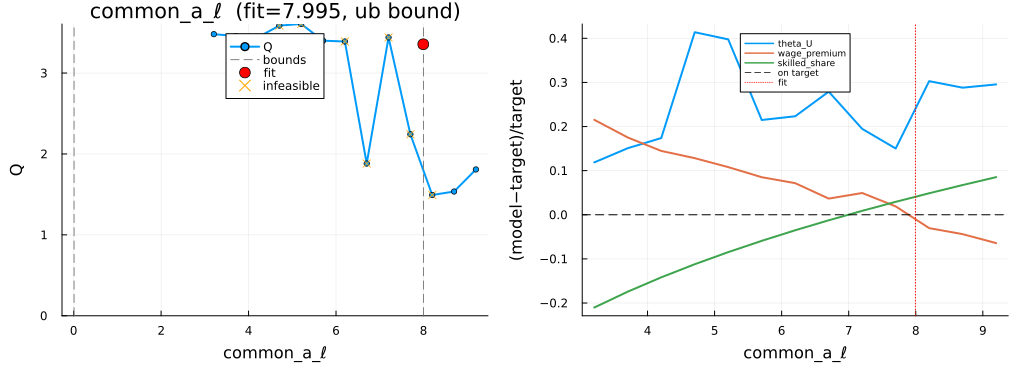

→ common_a_ℓ:  WIDEN BOUND — Q keeps falling past the ub bound (best @ 8.6991, Q=1.5357 < 3.3558). Box is in the wrong region.

→ unsk_bU:  GENUINE CORNER — Q minimised at/near the lb bound (best 0.0000). Likely moment tension; see the right panel for the fighting moment.



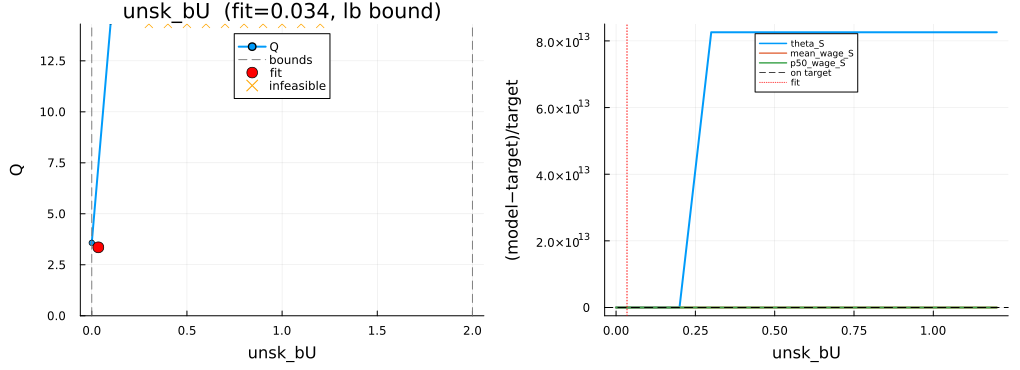

In [18]:
function sweep_param(cp,up,sp, blk, nm, spec; sim, Nx, npts=SWEEP_PTS)
    ps = first(p for p in spec.free if p.block===blk && p.name===nm)
    v0 = get_par(cp,up,sp,blk,nm)
    nearest = abs(v0-ps.lb) <= abs(ps.ub-v0) ? :lb : :ub
    w = ps.ub - ps.lb; hlo,hhi = hard_range(nm)
    lo,hi = nearest === :ub ? (max(ps.ub-0.6w, hlo), min(ps.ub+0.15w, hhi)) :
                              (max(ps.lb-0.15w, hlo), min(ps.lb+0.6w, hhi))
    hi = max(hi, lo + 1e-6)
    grid = collect(range(lo, hi; length=npts))
    active = Symbol[k for k in keys(spec.moments) if spec.moments[k].weight > 0]
    Qs = fill(NaN, npts); feas = falses(npts); M = fill(NaN, npts, length(active))
    for (t,v) in enumerate(grid)
        try
            c,u,s = put_par(cp,up,sp,blk,nm,v)
            model,r = solve_model(c,u,s,sim;Nx=Nx,Np_U=Nx,Np_S=Nx)
            obj = compute_equilibrium_objects(model); mm = model_moments(obj)
            Qs[t] = compute_loss_matrix(mm, spec, spec.W)
            feas[t] = feasibility(obj, r)[1]
            for (j,k) in enumerate(active); M[t,j] = getproperty(mm,k); end
        catch
        end
    end
    return (ps=ps, v0=v0, nearest=nearest, grid=grid, Q=Qs, feas=feas, active=active, M=M)
end

function verdict(sw, Q0; tol_rel=0.01)
    ok = isfinite.(sw.Q) .& sw.feas
    any(ok) || return "no feasible points in the sweep — widen HARD range or inspect the solver here."
    g = sw.grid[ok]; q = sw.Q[ok]; i = argmin(q); gmin = g[i]; qmin = q[i]; ps = sw.ps
    interior = (gmin > ps.lb + 1e-6*(ps.ub-ps.lb)) && (gmin < ps.ub - 1e-6*(ps.ub-ps.lb))
    beyond   = sw.nearest === :ub ? (gmin > ps.ub) : (gmin < ps.lb)
    improved = qmin < Q0*(1 - tol_rel)
    if beyond && improved
        return @sprintf("WIDEN BOUND — Q keeps falling past the %s bound (best @ %.4f, Q=%.4f < %.4f). Box is in the wrong region.", sw.nearest, gmin, qmin, Q0)
    elseif interior && improved
        return @sprintf("OPTIMISER MISSED IT — interior %.4f gives Q=%.4f < %.4f. A better point exists inside the box; strengthen global search/polish.", gmin, qmin, Q0)
    else
        return @sprintf("GENUINE CORNER — Q minimised at/near the %s bound (best %.4f). Likely moment tension; see the right panel for the fighting moment.", sw.nearest, gmin)
    end
end

labct = reports[LAB_WINDOW].corners
cornered_rows = labct[labct.cornered, :]
if nrow(cornered_rows) == 0
    println("No cornered parameters at LAB_WINDOW=$LAB_WINDOW (tol=$CORNER_TOL). Lower CORNER_TOL to inspect near-corners.")
else
    for rrow in eachrow(cornered_rows)
        sw = sweep_param(cp0,up0,sp0, rrow.block, rrow.name, spec; sim=LAB_SIM, Nx=LAB_NX)
        rng  = [maximum(finite_only(sw.M[:,j])) - minimum(finite_only(sw.M[:,j])) for j in 1:length(sw.active)]
        topj = sortperm(rng, rev=true)[1:min(3, length(sw.active))]

        qfin = filter(isfinite, sw.Q)
        ymax = isempty(qfin) ? 1.0 : min(maximum(qfin), 4*max(Q0, minimum(qfin)) + 1e-9)
        p1 = plot(sw.grid, sw.Q; lw=2, marker=:circle, ms=3, label="Q", legend=:top,
                  xlabel=string(rrow.param), ylabel="Q", ylims=(0, ymax),
                  title=@sprintf("%s  (fit=%.3f, %s bound)", rrow.param, sw.v0, sw.nearest))
        vline!(p1, [sw.ps.lb, sw.ps.ub]; ls=:dash, c=:gray, label="bounds")
        scatter!(p1, [sw.v0], [Q0]; c=:red, ms=6, label="fit")
        bad = .!(isfinite.(sw.Q) .& sw.feas)
        any(bad) && scatter!(p1, sw.grid[bad], min.(sw.Q[bad], ymax); c=:orange, m=:x, label="infeasible")

        p2 = plot(; xlabel=string(rrow.param), ylabel="(model−target)/target",
                  legend=:top, legendfontsize=6)
        for j in topj
            tj = spec.moments[sw.active[j]].value
            rel = tj != 0 ? (sw.M[:,j] .- tj) ./ tj : (sw.M[:,j] .- tj)
            plot!(p2, sw.grid, rel; lw=2, label=string(sw.active[j]))
        end
        hline!(p2, [0.0]; c=:black, ls=:dash, label="on target")
        vline!(p2, [sw.v0]; c=:red, ls=:dot, label="fit")

        display(plot(p1, p2; layout=(1,2), size=(1020,370), bottom_margin=6Plots.mm, left_margin=6Plots.mm))
        println("→ ", rrow.param, ":  ", verdict(sw, Q0)); println()
    end
end

### 8 · Scratch

Everything from Part B is in scope: `cp0,up0,sp0` (the fit), `update`,
`set_field`, `solve_report`, `sweep_param`, `Q0`. Test *coordinated* moves here
(e.g. trade η against k, or β_S against γ_PS) — that is where the structure of
the model, not a blind search, tells you what to try.

In [19]:
# Example — a coordinated move: pull η_U inward and adjust k_U together.
# r1 = solve_report(cp0, update(up0; η=0.60, k=0.15), sp0; spec=spec, sim=LAB_SIM, Nx=LAB_NX)
# @printf("Q0=%.4f   Q1=%.4f   ΔQ=%+.4f\n", rep0.Q, r1.Q, r1.Q-rep0.Q)


### Notes & caveats

- **Q decomposition** is exact for the diagonal weight schemes (`_equalW`,
  `_diagonalW`, `_compressedW`). Under a full Σ̂⁻¹ the off-diagonal cross-terms
  are omitted, so `pct_of_Q` is indicative only.
- **Grid.** Part A reproduces the estimation grid (from the bundle); Part B uses
  `LAB_NX` for speed. Compare lab results against `Q0` (same grid), never against
  the estimation-grid Q.
- **Verdicts are heuristics** to point you at the right experiment, not proofs.
  A "GENUINE CORNER" reading is the cue to look at the right-hand panel: the
  moment whose deviation is *minimised away from* the fit is the one in tension
  with whatever the cornered parameter is trying to match.
- **Feasibility.** `feasibility()` mirrors the `Inf` filters inside
  `smm_objective` (empty segment, degenerate/non-monotone τ). The sweeps still
  plot Q in infeasible regions (orange ×) so you can see the whole surface —
  the optimiser could not.